# Практическая работа 2
## Работа с данными для хранения больших данных: Parquet, Avro

In [1]:
import subprocess, sys

required = {
    'pyarrow': 'pyarrow',
    'fastavro': 'fastavro',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
}
for module, pkg in required.items():
    try:
        __import__(module)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Все зависимости установлены.')

import os
import time
import json
import io
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import fastavro
import matplotlib.pyplot as plt

os.makedirs('data', exist_ok=True)

print(f'pandas  {pd.__version__}')
print(f'pyarrow {pa.__version__}')
print(f'fastavro {fastavro.__version__}')

Все зависимости установлены.


pandas  3.0.2
pyarrow 24.0.0
fastavro 1.12.2


---
## Задание 1. Изучить недостатки CSV для больших данных

### 1.1 Генерация датасета 100k+ строк

In [2]:
np.random.seed(42)
N = 100_000

start_date = pd.Timestamp('2024-01-01')
timestamps = [start_date + pd.Timedelta(seconds=i * 3) for i in range(N)]

df = pd.DataFrame({
    'order_id':  np.arange(1, N + 1),
    'user_id':   np.random.randint(1, 10_001, N),
    'item_id':   np.random.randint(1, 1_001, N),
    'price':     np.round(np.random.uniform(10.0, 5000.0, N), 2),
    'quantity':  np.random.randint(1, 20, N),
    'ts':        timestamps,
})

csv_path = 'data/sales.csv'

t0 = time.time()
df.to_csv(csv_path, index=False)
csv_write_time = time.time() - t0

csv_size = os.path.getsize(csv_path)

print(f'Датасет: {N:,} строк x {df.shape[1]} колонок')
print(f'CSV записан за {csv_write_time:.3f} сек')
print(f'Размер CSV-файла: {csv_size / 1024 / 1024:.2f} МБ')
print()
print(df.dtypes)
print()
print(df.head(3))

Датасет: 100,000 строк x 6 колонок
CSV записан за 0.339 сек
Размер CSV-файла: 4.28 МБ

order_id             int64
user_id              int64
item_id              int64
price              float64
quantity             int64
ts          datetime64[us]
dtype: object

   order_id  user_id  item_id    price  quantity                  ts
0         1     7271      511  3452.62        19 2024-01-01 00:00:00
1         2      861      588  4833.02        17 2024-01-01 00:00:03
2         3     5391      694  1659.63        15 2024-01-01 00:00:06


In [3]:
# Чтение CSV и замер времени
t0 = time.time()
df_csv = pd.read_csv(csv_path)
csv_read_time = time.time() - t0

print(f'CSV прочитан за {csv_read_time:.3f} сек')
print(f'Типы после чтения CSV:')
print(df_csv.dtypes)

print()
print('=== Проблемы CSV для больших данных (ответ на задание 1.2) ===')
issues = """
1. Объём: CSV не сжимает данные. Числа хранятся как текст, что увеличивает
   размер файла по сравнению с бинарными форматами в 3-5 раз.

2. Отсутствие типов: CSV не хранит информацию о типах колонок.
   После чтения timestamp превращается в object (строку), а не в datetime.
   Каждый раз нужно явно задавать dtype или конвертировать.

3. Отсутствие сжатия: CSV не поддерживает встроенное сжатие.
   Для gzip-CSV теряется возможность случайного доступа.

4. Отсутствие эволюции схемы: добавление новой колонки нарушает
   совместимость со старыми читателями.

5. Медленный аналитический доступ: чтобы получить одну колонку,
   необходимо прочитать весь файл (строчная модель хранения).
"""
print(issues)

CSV прочитан за 0.227 сек
Типы после чтения CSV:
order_id      int64
user_id       int64
item_id       int64
price       float64
quantity      int64
ts              str
dtype: object

=== Проблемы CSV для больших данных (ответ на задание 1.2) ===

1. Объём: CSV не сжимает данные. Числа хранятся как текст, что увеличивает
   размер файла по сравнению с бинарными форматами в 3-5 раз.

2. Отсутствие типов: CSV не хранит информацию о типах колонок.
   После чтения timestamp превращается в object (строку), а не в datetime.
   Каждый раз нужно явно задавать dtype или конвертировать.

3. Отсутствие сжатия: CSV не поддерживает встроенное сжатие.
   Для gzip-CSV теряется возможность случайного доступа.

4. Отсутствие эволюции схемы: добавление новой колонки нарушает
   совместимость со старыми читателями.

5. Медленный аналитический доступ: чтобы получить одну колонку,
   необходимо прочитать весь файл (строчная модель хранения).



---
## Задание 2. Работа с Parquet

In [4]:
# Приведение типов перед записью в Parquet
df_typed = df.copy()
df_typed['ts']    = pd.to_datetime(df_typed['ts'])
df_typed['price'] = df_typed['price'].astype('float32')

print('Типы после приведения:')
print(df_typed.dtypes)

Типы после приведения:
order_id             int64
user_id              int64
item_id              int64
price              float32
quantity             int64
ts          datetime64[us]
dtype: object


In [5]:
# Сохранение в Parquet: snappy-сжатие
parquet_snappy = 'data/sales_snappy.parquet'
t0 = time.time()
df_typed.to_parquet(parquet_snappy, engine='pyarrow', compression='snappy', index=False)
parquet_snappy_write = time.time() - t0

# Сохранение в Parquet: gzip-сжатие
parquet_gzip = 'data/sales_gzip.parquet'
t0 = time.time()
df_typed.to_parquet(parquet_gzip, engine='pyarrow', compression='gzip', index=False)
parquet_gzip_write = time.time() - t0

snappy_size = os.path.getsize(parquet_snappy)
gzip_size   = os.path.getsize(parquet_gzip)

print('=== Сравнение размеров файлов ===')
print(f'CSV (без сжатия):    {csv_size / 1024 / 1024:.2f} МБ')
print(f'Parquet (snappy):    {snappy_size / 1024 / 1024:.2f} МБ  '
      f'(x{csv_size / snappy_size:.1f} меньше CSV)')
print(f'Parquet (gzip):      {gzip_size / 1024 / 1024:.2f} МБ  '
      f'(x{csv_size / gzip_size:.1f} меньше CSV)')

print('\n=== Время записи ===')
print(f'CSV write:           {csv_write_time:.3f} сек')
print(f'Parquet (snappy) write: {parquet_snappy_write:.3f} сек')
print(f'Parquet (gzip) write:   {parquet_gzip_write:.3f} сек')

=== Сравнение размеров файлов ===
CSV (без сжатия):    4.28 МБ
Parquet (snappy):    2.29 МБ  (x1.9 меньше CSV)
Parquet (gzip):      1.70 МБ  (x2.5 меньше CSV)

=== Время записи ===
CSV write:           0.339 сек
Parquet (snappy) write: 0.051 сек
Parquet (gzip) write:   1.480 сек


In [6]:
# Сравнение времени чтения CSV vs Parquet
t0 = time.time()
df_pq = pd.read_parquet(parquet_snappy, engine='pyarrow')
parquet_read_time = time.time() - t0

print('=== Сравнение времени чтения ===')
print(f'CSV read:            {csv_read_time:.3f} сек')
print(f'Parquet read:        {parquet_read_time:.3f} сек')
print(f'Parquet быстрее в {csv_read_time / parquet_read_time:.1f} раз')

print('\n=== Типы после чтения Parquet (типы сохраняются!) ===')
print(df_pq.dtypes)

print('\n=== Первые 3 строки ===')
print(df_pq.head(3))

=== Сравнение времени чтения ===
CSV read:            0.227 сек
Parquet read:        0.168 сек
Parquet быстрее в 1.4 раз

=== Типы после чтения Parquet (типы сохраняются!) ===
order_id             int64
user_id              int64
item_id              int64
price              float32
quantity             int64
ts          datetime64[us]
dtype: object

=== Первые 3 строки ===
   order_id  user_id  item_id        price  quantity                  ts
0         1     7271      511  3452.620117        19 2024-01-01 00:00:00
1         2      861      588  4833.020020        17 2024-01-01 00:00:03
2         3     5391      694  1659.630005        15 2024-01-01 00:00:06


In [7]:
# Column pruning: чтение только нужных колонок
t0 = time.time()
df_cols = pd.read_parquet(parquet_snappy, engine='pyarrow', columns=['user_id', 'price'])
col_read_time = time.time() - t0

cols_size_mb = df_cols.memory_usage(deep=True).sum() / 1024 / 1024
full_size_mb = df_pq.memory_usage(deep=True).sum() / 1024 / 1024

print('=== Column pruning: чтение только user_id, price ===')
print(f'Время чтения 2 колонок:   {col_read_time:.4f} сек')
print(f'Время чтения всех колонок: {parquet_read_time:.4f} сек')
print(f'Объем в памяти (2 кол.):  {cols_size_mb:.2f} МБ')
print(f'Объем в памяти (полный):  {full_size_mb:.2f} МБ')
print()
print(df_cols.head(3))


=== Column pruning: чтение только user_id, price ===
Время чтения 2 колонок:   0.0199 сек
Время чтения всех колонок: 0.1679 сек
Объем в памяти (2 кол.):  1.14 МБ
Объем в памяти (полный):  4.20 МБ

   user_id        price
0     7271  3452.620117
1      861  4833.020020
2     5391  1659.630005

=== Почему Parquet быстрее при аналитических запросах? ===

Parquet - колоночно-ориентированный формат (columnar storage).
Данные каждой колонки хранятся рядом на диске.

При аналитическом запросе (например, AVG(price) GROUP BY user_id)
нужно прочитать только 2 колонки из 6 - читается 1/3 данных.
В CSV при чтении любого столбца читается вся строка целиком.

Дополнительно Parquet хранит min/max статистики по row-group,
что позволяет пропускать целые блоки при фильтрации (predicate pushdown).
Колоночное хранение также обеспечивает лучшее сжатие,
так как однотипные данные идут подряд.

Лучшие сценарии Parquet: DWH, аналитические запросы, Data Lake,
агрегации по подмножеству колонок.



In [8]:
# Метаданные Parquet-файла
parquet_file = pq.ParquetFile(parquet_snappy)
meta = parquet_file.metadata

print('=== Метаданные Parquet-файла ===')
print(f'Число строк:          {meta.num_rows}')
print(f'Число колонок:        {meta.num_columns}')
print(f'Число row-групп:      {meta.num_row_groups}')
print(f'Версия формата:       {meta.format_version}')
print()
print('=== Схема Parquet ===')
print(parquet_file.schema_arrow)

=== Метаданные Parquet-файла ===
Число строк:          100000
Число колонок:        6
Число row-групп:      1
Версия формата:       2.6

=== Схема Parquet ===
order_id: int64
user_id: int64
item_id: int64
price: float
quantity: int64
ts: timestamp[us]
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 765


---
## Задание 3. Работа с Avro и схемой

### 3.1 Определение Avro-схемы

In [9]:
# Avro-схема v1 для нашего датасета
avro_schema_v1 = {
    'type': 'record',
    'name': 'SaleRecord',
    'namespace': 'com.example.sales',
    'doc': 'Запись о продаже, версия 1',
    'fields': [
        {'name': 'order_id',  'type': 'long',   'doc': 'ID заказа'},
        {'name': 'user_id',   'type': 'int',    'doc': 'ID пользователя'},
        {'name': 'item_id',   'type': 'int',    'doc': 'ID товара'},
        {'name': 'price',     'type': 'float',  'doc': 'Цена товара'},
        {'name': 'quantity',  'type': 'int',    'doc': 'Количество'},
        {'name': 'ts',        'type': 'string', 'doc': 'Временная метка (ISO 8601)'},
    ]
}

parsed_schema_v1 = fastavro.parse_schema(avro_schema_v1)
print('=== Avro-схема v1 ===')
print(json.dumps(avro_schema_v1, ensure_ascii=False, indent=2))

=== Avro-схема v1 ===
{
  "type": "record",
  "name": "SaleRecord",
  "namespace": "com.example.sales",
  "doc": "Запись о продаже, версия 1",
  "fields": [
    {
      "name": "order_id",
      "type": "long",
      "doc": "ID заказа"
    },
    {
      "name": "user_id",
      "type": "int",
      "doc": "ID пользователя"
    },
    {
      "name": "item_id",
      "type": "int",
      "doc": "ID товара"
    },
    {
      "name": "price",
      "type": "float",
      "doc": "Цена товара"
    },
    {
      "name": "quantity",
      "type": "int",
      "doc": "Количество"
    },
    {
      "name": "ts",
      "type": "string",
      "doc": "Временная метка (ISO 8601)"
    }
  ]
}


In [10]:
# Запись данных в Avro (используем первые 1000 строк для демонстрации)
avro_path_v1 = 'data/sales_v1.avro'

# Подготовка записей: ts -> строка
sample_df = df_typed.head(1000).copy()
sample_df['ts'] = sample_df['ts'].dt.strftime('%Y-%m-%dT%H:%M:%S')
sample_df['order_id'] = sample_df['order_id'].astype(int)
sample_df['user_id']  = sample_df['user_id'].astype(int)
sample_df['item_id']  = sample_df['item_id'].astype(int)
sample_df['quantity'] = sample_df['quantity'].astype(int)
sample_df['price']    = sample_df['price'].astype(float)

records_v1 = sample_df.to_dict(orient='records')

t0 = time.time()
with open(avro_path_v1, 'wb') as f:
    fastavro.writer(f, parsed_schema_v1, records_v1, codec='deflate')
avro_write_time = time.time() - t0

avro_size = os.path.getsize(avro_path_v1)
print(f'Avro v1 записан ({len(records_v1)} записей) за {avro_write_time:.3f} сек')
print(f'Размер Avro-файла: {avro_size / 1024:.1f} КБ')

Avro v1 записан (1000 записей) за 0.004 сек
Размер Avro-файла: 14.0 КБ


In [11]:
# Чтение Avro-файла и проверка типов
t0 = time.time()
with open(avro_path_v1, 'rb') as f:
    reader = fastavro.reader(f)
    read_schema = reader.writer_schema
    records_read = list(reader)
avro_read_time = time.time() - t0

df_avro = pd.DataFrame(records_read)

print(f'Avro прочитан за {avro_read_time:.3f} сек, {len(df_avro)} записей')
print()
print('=== Типы корректны ===')
print(df_avro.dtypes)
print()
print(df_avro.head(3))

Avro прочитан за 0.004 сек, 1000 записей

=== Типы корректны ===
order_id      int64
user_id       int64
item_id       int64
price       float64
quantity      int64
ts              str
dtype: object

   order_id  user_id  item_id        price  quantity                   ts
0         1     7271      511  3452.620117        19  2024-01-01T00:00:00
1         2      861      588  4833.020020        17  2024-01-01T00:00:03
2         3     5391      694  1659.630005        15  2024-01-01T00:00:06


### 3.2 Эволюция схемы Avro (forward/backward-совместимость)

In [12]:
# Avro-схема v2:
#   + добавлено поле 'discount' со значением по умолчанию 0.0
#   + поле 'item_id' объявлено необязательным (union с null)
avro_schema_v2 = {
    'type': 'record',
    'name': 'SaleRecord',
    'namespace': 'com.example.sales',
    'doc': 'Запись о продаже, версия 2',
    'fields': [
        {'name': 'order_id',  'type': 'long',
         'doc': 'ID заказа'},
        {'name': 'user_id',   'type': 'int',
         'doc': 'ID пользователя'},
        {'name': 'item_id',   'type': ['null', 'int'], 'default': None,
         'doc': 'ID товара (необязательное поле)'},
        {'name': 'price',     'type': 'float',
         'doc': 'Цена товара'},
        {'name': 'quantity',  'type': 'int',
         'doc': 'Количество'},
        {'name': 'ts',        'type': 'string',
         'doc': 'Временная метка (ISO 8601)'},
        # Новое поле со значением по умолчанию - это backward-совместимо
        {'name': 'discount',  'type': 'float', 'default': 0.0,
         'doc': 'Скидка в процентах (новое поле v2)'},
    ]
}

parsed_schema_v2 = fastavro.parse_schema(avro_schema_v2)
print('=== Avro-схема v2 создана ===')
print('Изменения:')
print('  + добавлено поле discount (float, default=0.0)')
print('  + item_id стал nullable (union [null, int])')

=== Avro-схема v2 создана ===
Изменения:
  + добавлено поле discount (float, default=0.0)
  + item_id стал nullable (union [null, int])


In [13]:
# Запись новых данных по схеме v2
avro_path_v2 = 'data/sales_v2.avro'

records_v2 = []
for r in records_v1[:500]:
    rec = dict(r)
    rec['discount'] = round(np.random.uniform(0.0, 15.0), 2)
    records_v2.append(rec)

with open(avro_path_v2, 'wb') as f:
    fastavro.writer(f, parsed_schema_v2, records_v2, codec='deflate')

print(f'Avro v2 записан: {len(records_v2)} записей')

Avro v2 записан: 500 записей


In [14]:
# Backward-совместимость:
# читаем данные, записанные по схеме v1, используя reader-схему v2
# Avro должен подставить значение по умолчанию для поля discount

with open(avro_path_v1, 'rb') as f:
    records_v1_read_with_v2 = list(
        fastavro.reader(f, reader_schema=parsed_schema_v2)
    )

df_back = pd.DataFrame(records_v1_read_with_v2)

print('=== Backward-совместимость: старые данные (v1) читаем схемой v2 ===')
print(f'Строк: {len(df_back)}')
print(f'discount (должен быть 0.0 по умолчанию): {df_back["discount"].unique()}')
print()
print(df_back[['order_id', 'price', 'discount']].head(5))

=== Backward-совместимость: старые данные (v1) читаем схемой v2 ===
Строк: 1000
discount (должен быть 0.0 по умолчанию): [0.]

   order_id        price  discount
0         1  3452.620117       0.0
1         2  4833.020020       0.0
2         3  1659.630005       0.0
3         4   813.200012       0.0
4         5  4913.399902       0.0


In [15]:
# Forward-совместимость:
# читаем данные, записанные по схеме v2, используя reader-схему v1
# Avro должен проигнорировать неизвестное поле discount

with open(avro_path_v2, 'rb') as f:
    records_v2_read_with_v1 = list(
        fastavro.reader(f, reader_schema=parsed_schema_v1)
    )

df_fwd = pd.DataFrame(records_v2_read_with_v1)

print('=== Forward-совместимость: новые данные (v2) читаем схемой v1 ===')
print(f'Строк: {len(df_fwd)}')
print(f'Колонки: {list(df_fwd.columns)} (discount отсутствует - ожидаемо)')
print()
print(df_fwd.head(3))

=== Forward-совместимость: новые данные (v2) читаем схемой v1 ===
Строк: 500
Колонки: ['order_id', 'user_id', 'item_id', 'price', 'quantity', 'ts'] (discount отсутствует - ожидаемо)

   order_id  user_id  item_id        price  quantity                   ts
0         1     7271      511  3452.620117        19  2024-01-01T00:00:00
1         2      861      588  4833.020020        17  2024-01-01T00:00:03
2         3     5391      694  1659.630005        15  2024-01-01T00:00:06

=== Преимущество Avro-подхода к эволюции схем ===

Avro хранит схему вместе с данными в каждом файле.
Это позволяет:
  - добавлять новые поля (с default) без поломки старых читателей
    (backward-совместимость);
  - читать новые данные старым кодом, игнорируя новые поля
    (forward-совместимость).

В потоковых системах (Kafka + Schema Registry) Avro применяется
именно так: producer пишет по новой схеме v2, consumer на старой
версии продолжает работать без изменений.

В Hadoop-экосистеме Avro используется для inge

---
## Задание 4. Parquet vs Avro: сравнительный анализ

In [16]:
# Итоговая сравнительная таблица
comparison = pd.DataFrame([
    {
        'Критерий': 'Модель хранения',
        'Parquet': 'Колоночная (columnar): данные каждой колонки хранятся вместе',
        'Avro': 'Строчная (row-based): каждая запись хранится целиком'
    },
    {
        'Критерий': 'Основной сценарий применения',
        'Parquet': 'Аналитические запросы по подмножеству колонок, DWH, Data Lake',
        'Avro': 'Потоковая передача данных, ingestion в Kafka, сериализация'
    },
    {
        'Критерий': 'Сжатие и скорость аналитических запросов',
        'Parquet': 'Очень хорошее: однотипные данные в колонке сжимаются лучше',
        'Avro': 'Хорошее для полных записей, хуже для выборки колонок'
    },
    {
        'Критерий': 'Эволюция схем',
        'Parquet': 'Поддерживается, но без встроенного механизма default-значений',
        'Avro': 'Первоклассная поддержка: backward/forward-совместимость с defaults'
    },
    {
        'Критерий': 'Типичные интеграции',
        'Parquet': 'Spark, Hive, Presto, BigQuery, Athena, Delta Lake',
        'Avro': 'Kafka, Kafka Schema Registry, Hadoop HDFS, Flink'
    },
])

print('=== Сравнительная таблица: Parquet vs Avro ===')
for _, row in comparison.iterrows():
    print(f'\n[{row["Критерий"]}]')
    print(f'  Parquet: {row["Parquet"]}')
    print(f'  Avro:    {row["Avro"]}')

=== Сравнительная таблица: Parquet vs Avro ===

[Модель хранения]
  Parquet: Колоночная (columnar): данные каждой колонки хранятся вместе
  Avro:    Строчная (row-based): каждая запись хранится целиком

[Основной сценарий применения]
  Parquet: Аналитические запросы по подмножеству колонок, DWH, Data Lake
  Avro:    Потоковая передача данных, ingestion в Kafka, сериализация

[Сжатие и скорость аналитических запросов]
  Parquet: Очень хорошее: однотипные данные в колонке сжимаются лучше
  Avro:    Хорошее для полных записей, хуже для выборки колонок

[Эволюция схем]
  Parquet: Поддерживается, но без встроенного механизма default-значений
  Avro:    Первоклассная поддержка: backward/forward-совместимость с defaults

[Типичные интеграции]
  Parquet: Spark, Hive, Presto, BigQuery, Athena, Delta Lake
  Avro:    Kafka, Kafka Schema Registry, Hadoop HDFS, Flink


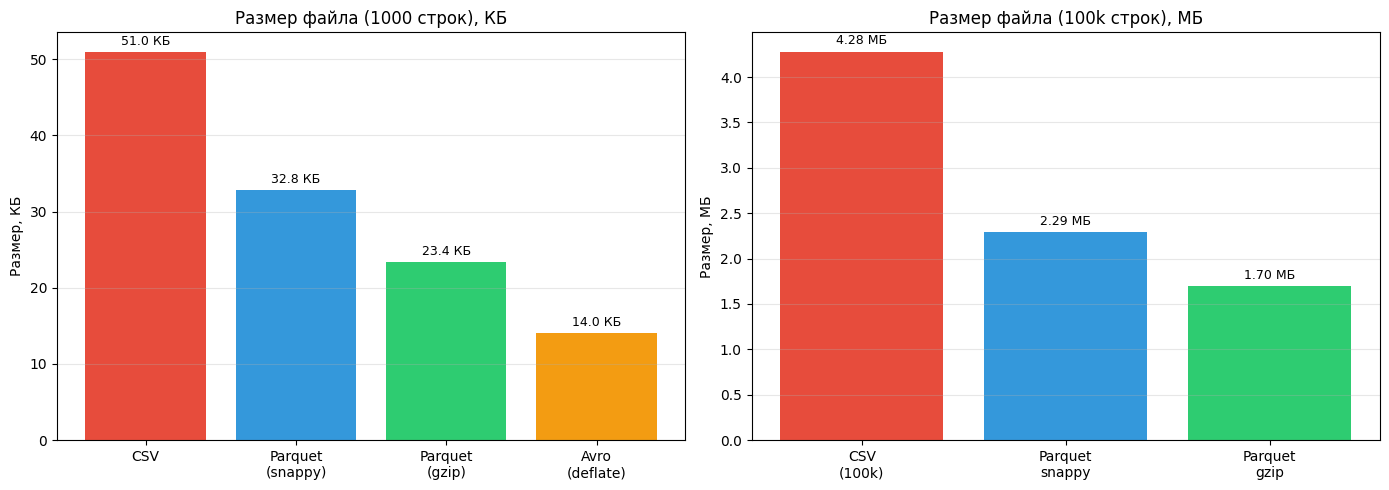

График сохранен в data/parquet_avro_comparison.png


In [17]:
# Визуализация сравнения размеров файлов
# (для одинакового числа строк - 1000)

csv_1k_path = 'data/sales_1k.csv'
sample_df.to_csv(csv_1k_path, index=False)

pq_1k_snappy = 'data/sales_1k_snappy.parquet'
pq_1k_gzip   = 'data/sales_1k_gzip.parquet'
sample_typed = sample_df.copy()
sample_typed['ts'] = pd.to_datetime(sample_typed['ts'])
sample_typed.to_parquet(pq_1k_snappy, compression='snappy', index=False)
sample_typed.to_parquet(pq_1k_gzip,   compression='gzip',   index=False)

sizes = {
    'CSV': os.path.getsize(csv_1k_path) / 1024,
    'Parquet\n(snappy)': os.path.getsize(pq_1k_snappy) / 1024,
    'Parquet\n(gzip)':   os.path.getsize(pq_1k_gzip) / 1024,
    'Avro\n(deflate)':   os.path.getsize(avro_path_v1) / 1024,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График размеров (1000 строк)
ax = axes[0]
bars = ax.bar(sizes.keys(), sizes.values(),
              color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
ax.set_title('Размер файла (1000 строк), КБ')
ax.set_ylabel('Размер, КБ')
for bar, val in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f} КБ', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# График сжатия полного датасета (100k строк)
full_sizes = {
    'CSV\n(100k)':    csv_size / 1024 / 1024,
    'Parquet\nsnappy': snappy_size / 1024 / 1024,
    'Parquet\ngzip':   gzip_size / 1024 / 1024,
}
ax2 = axes[1]
bars2 = ax2.bar(full_sizes.keys(), full_sizes.values(),
                color=['#e74c3c', '#3498db', '#2ecc71'])
ax2.set_title('Размер файла (100k строк), МБ')
ax2.set_ylabel('Размер, МБ')
for bar, val in zip(bars2, full_sizes.values()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{val:.2f} МБ', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/parquet_avro_comparison.png', dpi=100)
plt.show()
print('График сохранен в data/parquet_avro_comparison.png')

In [18]:
# Итоговый бенчмарк: запись и чтение для трех форматов
bench_results = []

for n in [10_000, 50_000, 100_000]:
    sub = df_typed.head(n).copy()
    sub_str = sub.copy()
    sub_str['ts'] = sub_str['ts'].dt.strftime('%Y-%m-%dT%H:%M:%S')
    sub_str['order_id'] = sub_str['order_id'].astype(int)
    sub_str['user_id']  = sub_str['user_id'].astype(int)
    sub_str['item_id']  = sub_str['item_id'].astype(int)
    sub_str['quantity'] = sub_str['quantity'].astype(int)
    sub_str['price']    = sub_str['price'].astype(float)

    # CSV
    p = f'data/bench_{n}.csv'
    t0 = time.time(); sub.to_csv(p, index=False); wt = time.time() - t0
    t0 = time.time(); pd.read_csv(p); rt = time.time() - t0
    bench_results.append({'n': n, 'format': 'csv', 'write': wt, 'read': rt,
                          'size_kb': os.path.getsize(p) / 1024})

    # Parquet snappy
    p = f'data/bench_{n}.parquet'
    t0 = time.time(); sub.to_parquet(p, compression='snappy', index=False); wt = time.time() - t0
    t0 = time.time(); pd.read_parquet(p); rt = time.time() - t0
    bench_results.append({'n': n, 'format': 'parquet', 'write': wt, 'read': rt,
                          'size_kb': os.path.getsize(p) / 1024})

    # Avro
    p = f'data/bench_{n}.avro'
    recs = sub_str.to_dict(orient='records')
    t0 = time.time()
    with open(p, 'wb') as f_avro:
        fastavro.writer(f_avro, parsed_schema_v1, recs, codec='deflate')
    wt = time.time() - t0
    t0 = time.time()
    with open(p, 'rb') as f_avro:
        _ = list(fastavro.reader(f_avro))
    rt = time.time() - t0
    bench_results.append({'n': n, 'format': 'avro', 'write': wt, 'read': rt,
                          'size_kb': os.path.getsize(p) / 1024})

df_bench = pd.DataFrame(bench_results)
print('=== Итоговый бенчмарк ===')
print(df_bench.to_string(index=False))

=== Итоговый бенчмарк ===
     n  format    write     read     size_kb
 10000     csv 0.038933 0.020453  428.466797
 10000 parquet 0.019228 0.007907  256.262695
 10000    avro 0.032141 0.048426  134.532227
 50000     csv 0.166387 0.106038 2185.852539
 50000 parquet 0.025035 0.007717 1194.140625
 50000    avro 0.159616 0.228163  687.311523
100000     csv 0.301442 0.229493 4382.367188
100000 parquet 0.055256 0.013099 2345.614258
100000    avro 0.319084 0.400195 1378.870117


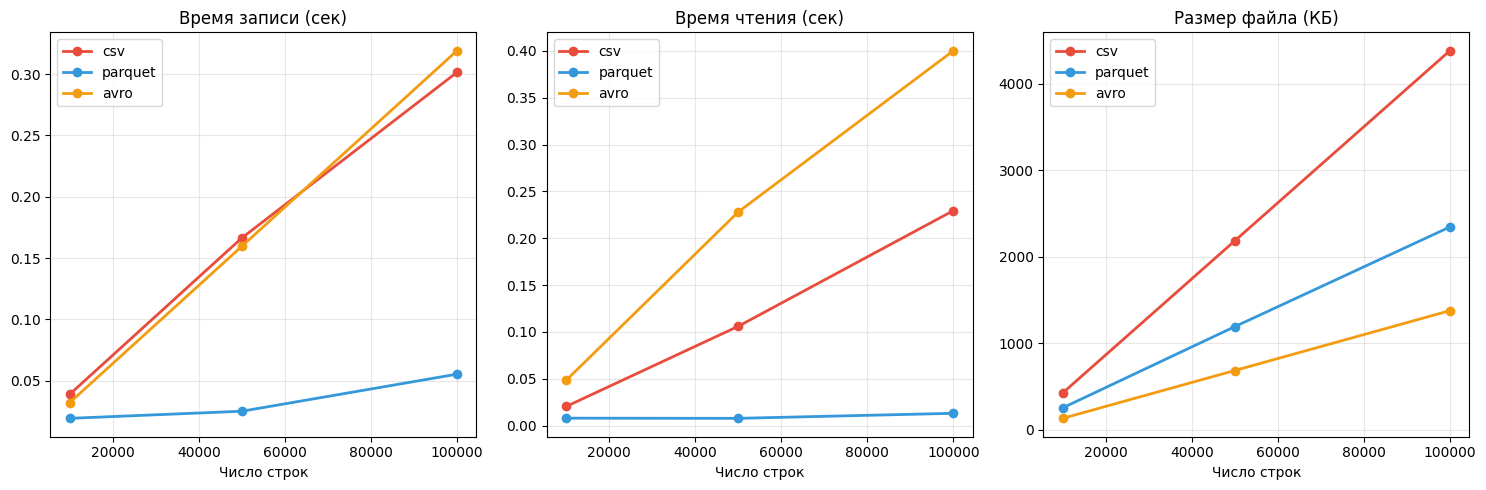

График бенчмарка сохранен в data/benchmark_full.png


In [19]:
# Визуализация итогового бенчмарка
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'csv': '#e74c3c', 'parquet': '#3498db', 'avro': '#f39c12'}

for metric, title, ax in zip(
    ['write', 'read', 'size_kb'],
    ['Время записи (сек)', 'Время чтения (сек)', 'Размер файла (КБ)'],
    axes
):
    for fmt in ['csv', 'parquet', 'avro']:
        sub = df_bench[df_bench['format'] == fmt]
        ax.plot(sub['n'], sub[metric], marker='o',
                label=fmt, color=colors[fmt], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Число строк')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/benchmark_full.png', dpi=100)
plt.show()
print('График бенчмарка сохранен в data/benchmark_full.png')